In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("customer_segmentation.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,22,15000,39
1,2,Female,25,18000,81
2,3,Female,47,50000,6
3,4,Male,52,60000,77
4,5,Male,46,52000,40


#univariable Analysis

In [4]:
df.describe()

,CustomerID,Age,Annual_Income,Spending_Score
count,20.00000,20.00000,20.000000,20.000000
mean,10.50000,34.65000,37900.000000,50.550000
std,5.91608,9.64788,15403.007225,33.725634
min,1.00000,22.00000,15000.000000,3.000000
25%,5.75000,26.75000,25750.000000,14.750000
50%,10.50000,32.00000,35500.000000,55.000000
75%,15.25000,42.75000,50500.000000,77.750000
max,20.00000,52.00000,65000.000000,99.000000


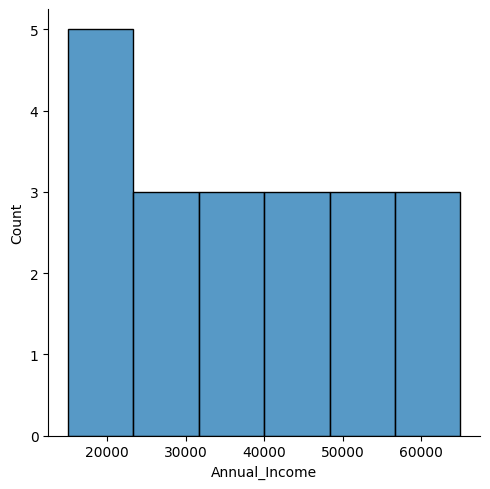

In [5]:
sns.displot(df['Annual_Income'])

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score'], dtype='str')

<Figure size 640x480 with 0 Axes>

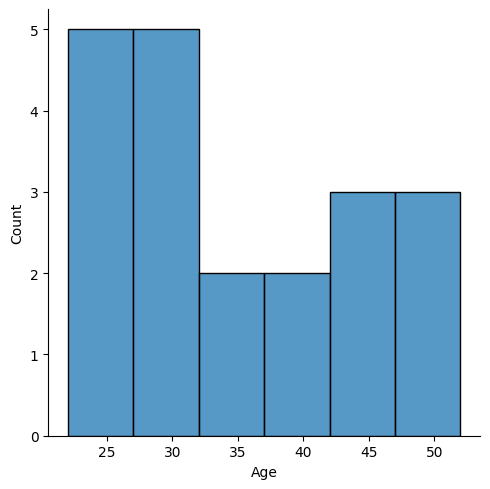

<Figure size 640x480 with 0 Axes>

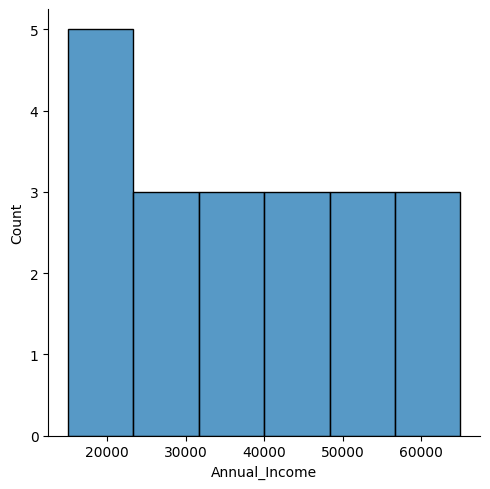

<Figure size 640x480 with 0 Axes>

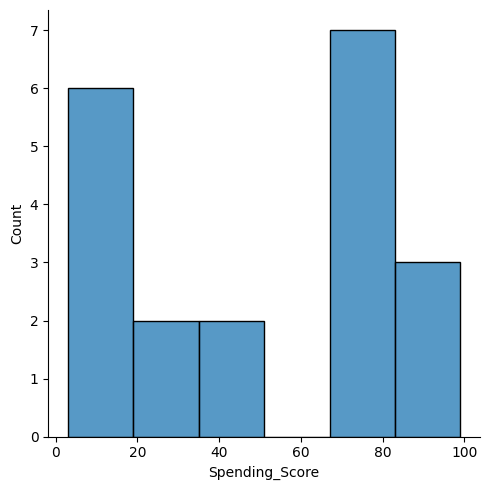

In [7]:
columns = ['Age', 'Annual_Income', 'Spending_Score']
for i in columns:
    plt.figure()
    sns.displot(df[i])

<Axes: xlabel='Annual_Income', ylabel='Density'>

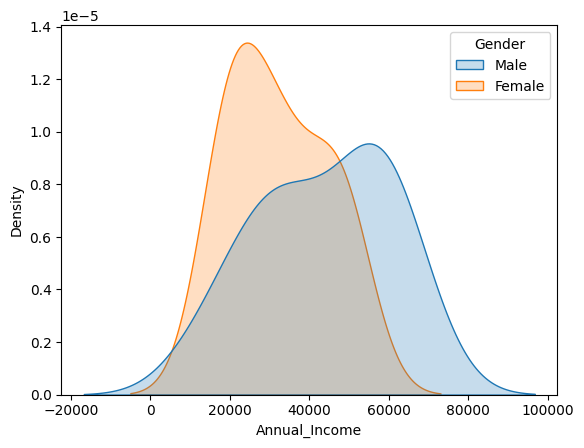

In [11]:
sns.kdeplot(data=df, x='Annual_Income', hue='Gender', fill=True)

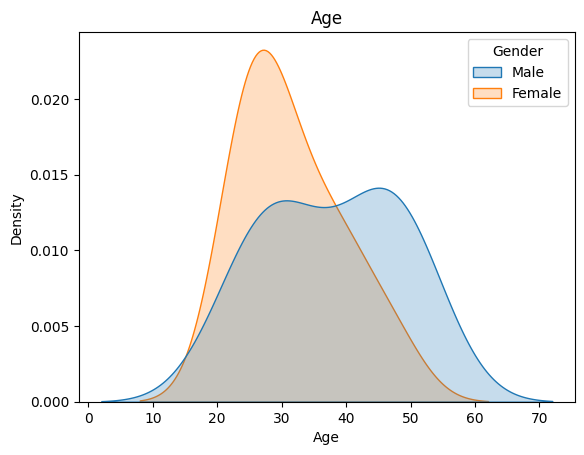

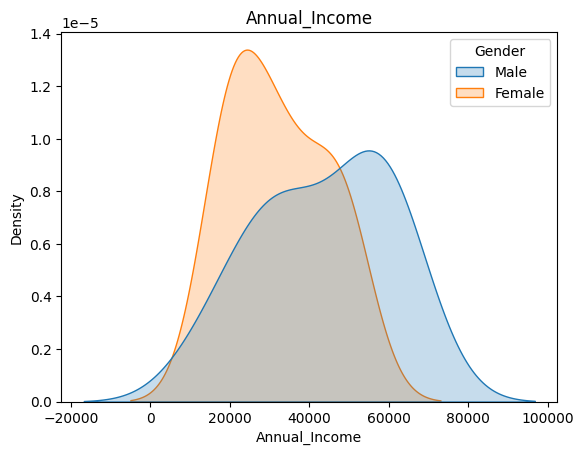

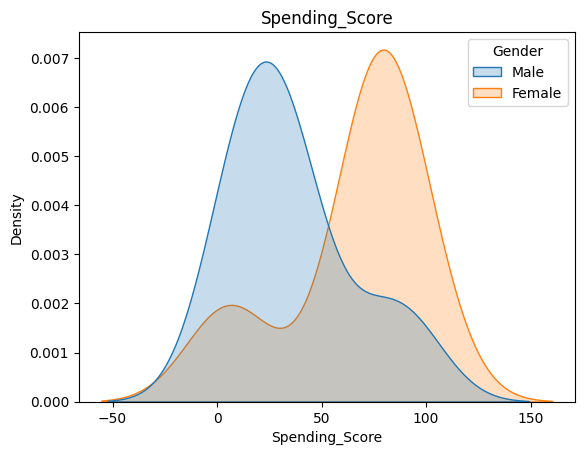

In [14]:
columns = ['Age', 'Annual_Income', 'Spending_Score']

for i in columns:
    plt.figure()
    sns.kdeplot(data=df, x=i, hue='Gender', fill=True)
    plt.title(i)

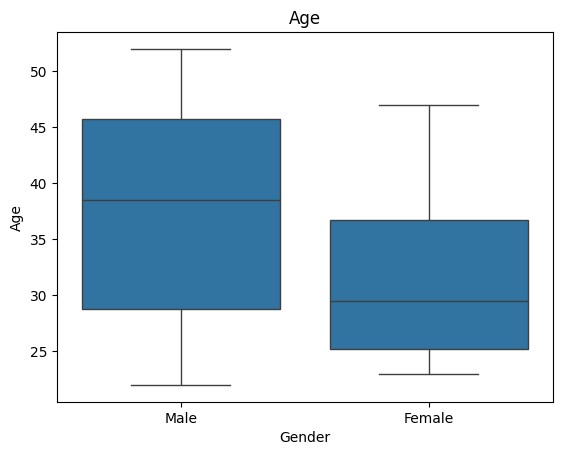

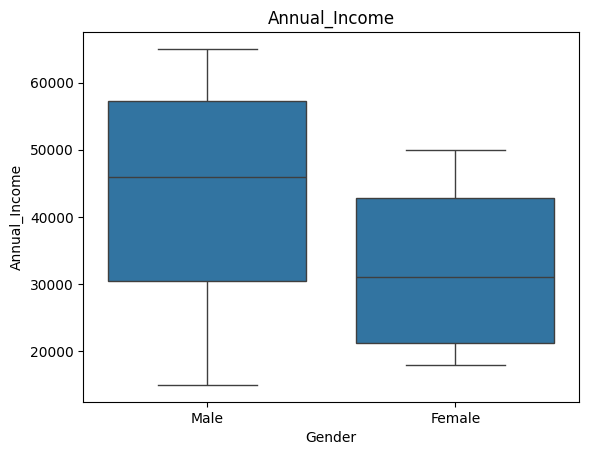

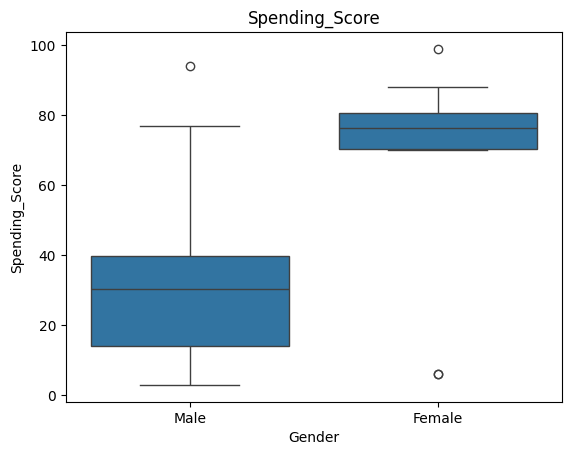

In [15]:
columns = ['Age', 'Annual_Income', 'Spending_Score']

for i in columns:
    plt.figure()
    sns.boxplot(data=df, x='Gender', y=df[i])
    plt.title(i)

In [16]:
df['Gender'].value_counts(normalize=True)

Gender
Male      0.5
Female    0.5
Name: proportion, dtype: float64

#bivariate analysis

<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

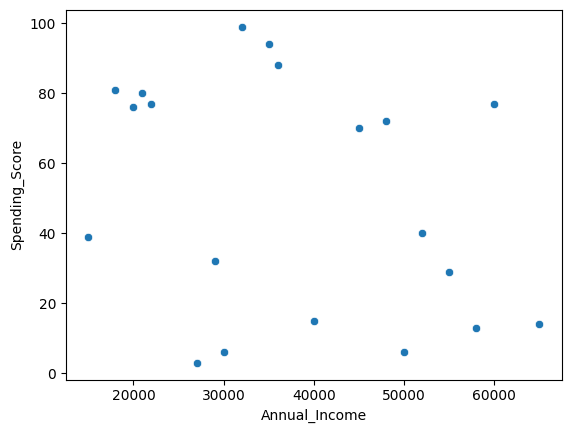

In [18]:
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score')

In [25]:
df = pd.read_csv("customer_segmentation.csv")


In [26]:
df = df.drop(columns=['CustomerID']) 

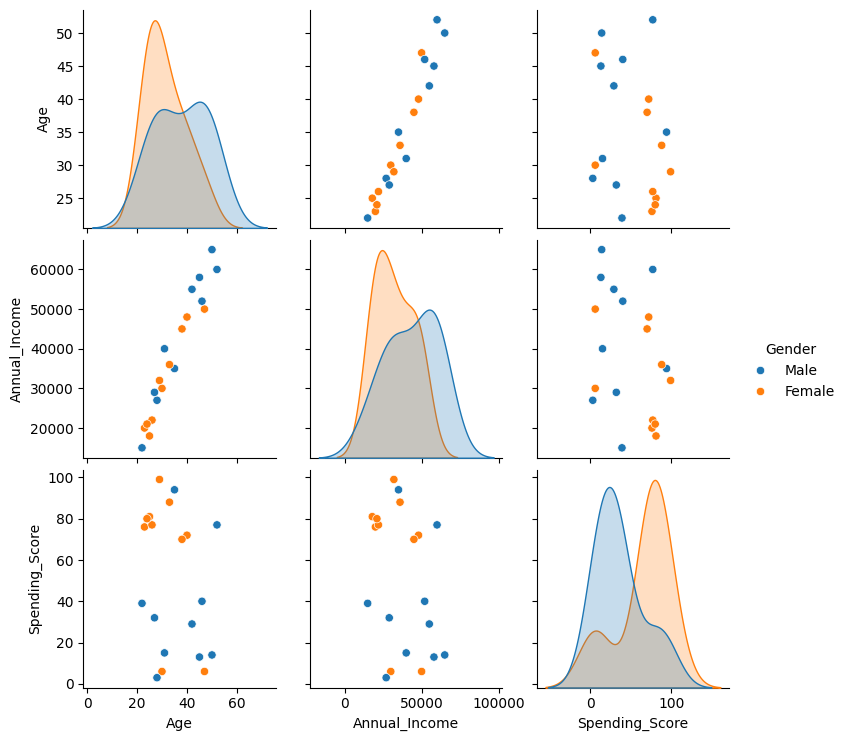

In [27]:
sns.pairplot(df, hue='Gender')

In [29]:
df.groupby('Gender')[['Age', 'Annual_Income', 'Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Gender,,,
Female,31.5,32200.0,65.5
Male,37.8,43600.0,35.6


In [31]:
df.corr(numeric_only=True)

,Age,Annual_Income,Spending_Score
Age,1.000000,0.968047,-0.267080
Annual_Income,0.968047,1.000000,-0.314071
Spending_Score,-0.267080,-0.314071,1.000000


In [34]:
corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()

<Axes: >

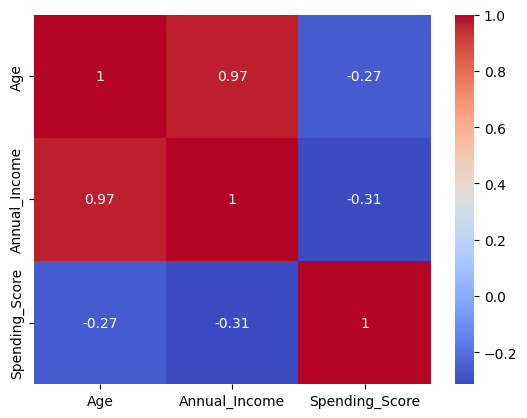

In [35]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

#clustering-univariate,bivariate,multivariate

In [55]:
clustering1 = KMeans(n_clusters=3)

In [56]:
clustering1.fit(df[['Annual_Income']])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [57]:
clustering1.labels_

array([1, 1, 2, 0, 2, 1, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1, 1, 2, 0, 1],
      dtype=int32)

In [58]:
df['Income Cluster'] = clustering1.labels_
df.head()

,Gender,Age,Annual_Income,Spending_Score,Income Cluster
0,Male,22,15000,39,1
1,Female,25,18000,81,1
2,Female,47,50000,6,2
3,Male,52,60000,77,0
4,Male,46,52000,40,2


In [59]:
df['Income Cluster'].value_counts()

Income Cluster
1    11
2     5
0     4
Name: count, dtype: int64

In [60]:
clustering1.inertia_

645909090.9090909

In [61]:
inertia_scores = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual_Income']])
    inertia_scores.append(kmeans.inertia_)

In [62]:
inertia_scores

[4507800000.0,
 993131313.1313131,
 492642857.14285713,
 321514285.71428573,
 137550000.0,
 97216666.66666666,
 83550000.0,
 52666666.66666667,
 41416666.66666667,
 32416666.666666668]

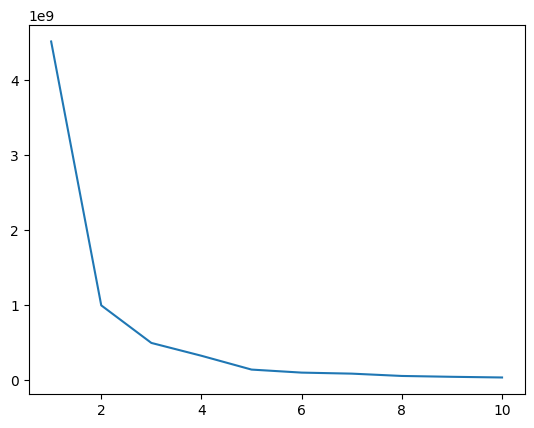

In [63]:
plt.plot(range(1,11),inertia_scores)

In [64]:
df.columns

Index(['Gender', 'Age', 'Annual_Income', 'Spending_Score', 'Income Cluster'], dtype='str')

In [66]:
df.groupby('Income Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Income Cluster,,,
0,47.250000,59500.000000,33.250000
1,27.454545,25909.090909,61.363636
2,40.400000,47000.000000,40.600000


#Bivariate Clustering

In [76]:
clustering2= KMeans(n_clusters=5)
clustering2.fit(df[['Annual_Income' , 'Spending_Score']])
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,Gender,Age,Annual_Income,Spending_Score,Income Cluster,Spending and Income Cluster
0,Male,22,15000,39,1,2
1,Female,25,18000,81,1,2
2,Female,47,50000,6,2,1
3,Male,52,60000,77,0,4
4,Male,46,52000,40,2,1


In [77]:
from sklearn.cluster import KMeans

inertia_scores2 = []

for i in range(1,11):
    kmeans2 = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans2.fit(df[['Annual_Income','Spending_Score']])
    inertia_scores2.append(kmeans2.inertia_)   

In [78]:
print(inertia_scores2)

[4507821610.950001, 993150065.6767677, 465122262.3607143, 233317850.48333335, 137566700.61666667, 97232873.2, 75181625.00000001, 53007369.833333336, 39004111.99999999, 28509506.666666664]


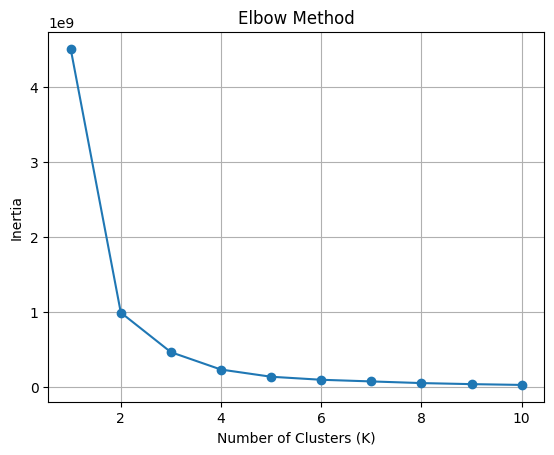

In [79]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), inertia_scores2, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [80]:
print(df[['Annual_Income','Spending_Score']].describe())

       Annual_Income  Spending_Score
count      20.000000       20.000000
mean    37900.000000       50.550000
std     15403.007225       33.725634
min     15000.000000        3.000000
25%     25750.000000       14.750000
50%     35500.000000       55.000000
75%     50500.000000       77.750000
max     65000.000000       99.000000


In [81]:
print(df[['Annual_Income','Spending_Score']].head())


   Annual_Income  Spending_Score
0          15000              39
1          18000              81
2          50000               6
3          60000              77
4          52000              40


In [82]:
print(df[['Annual_Income','Spending_Score']].dtypes)

Annual_Income     int64
Spending_Score    int64
dtype: object


In [91]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

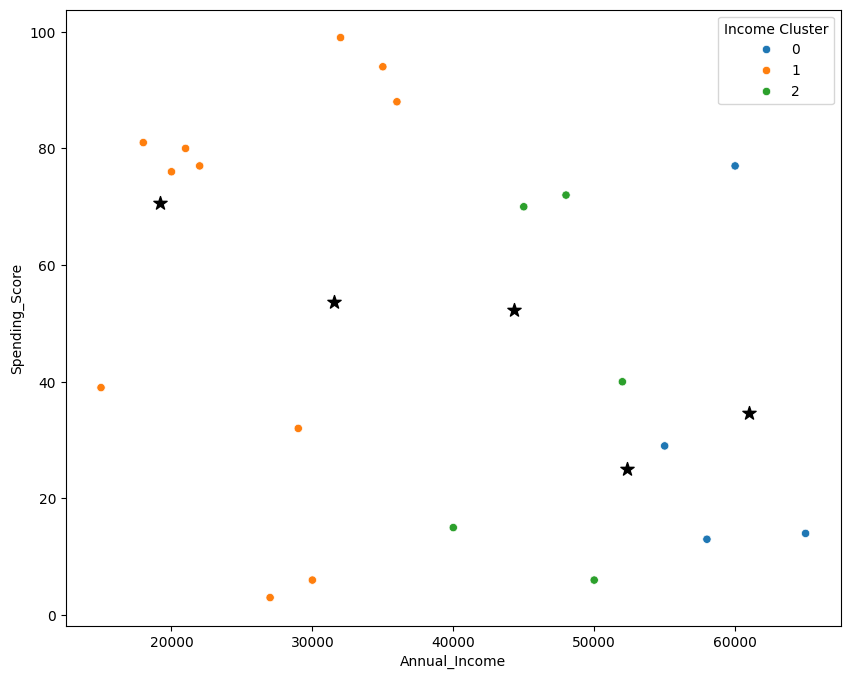

In [112]:
plt.figure(figsize=(10,8))
plt.scatter(x=centers['x'],y=centers['y'],s=100,c='black', marker='*')
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Income Cluster',
    palette='tab10'
)
plt.savefig('clustering_bivariate.png')

In [95]:
pd.crosstab(df['Spending and Income Cluster'], df['Gender'], normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.500000,0.500000
1,0.333333,0.666667
2,0.800000,0.200000
3,0.666667,0.333333
4,0.000000,1.000000


In [96]:
df.groupby('Spending and Income Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Spending and Income Cluster,,,
0,30.333333,31500.000000,53.666667
1,45.000000,52333.333333,25.000000
2,24.000000,19200.000000,70.600000
3,36.333333,44333.333333,52.333333
4,49.000000,61000.000000,34.666667


#multivariate clustering

In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scale = StandardScaler()

In [99]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Income Cluster,Spending and Income Cluster
0,Male,22,15000,39,1,2
1,Female,25,18000,81,1,2
2,Female,47,50000,6,2,1
3,Male,52,60000,77,0,4
4,Male,46,52000,40,2,1


In [101]:
dff = pd.get_dummies(df,drop_first=True)
dff.head()

,Age,Annual_Income,Spending_Score,Income Cluster,Spending and Income Cluster,Gender_Male
0,22,15000,39,1,2,True
1,25,18000,81,1,2,False
2,47,50000,6,2,1,False
3,52,60000,77,0,4,True
4,46,52000,40,2,1,True


In [102]:
dff.columns

Index(['Age', 'Annual_Income', 'Spending_Score', 'Income Cluster',
       'Spending and Income Cluster', 'Gender_Male'],
      dtype='str')

In [104]:
dff = dff[['Age', 'Annual_Income', 'Spending_Score', 'Gender_Male']]
dff.head()

,Age,Annual_Income,Spending_Score,Gender_Male
0,22,15000,39,True
1,25,18000,81,False
2,47,50000,6,False
3,52,60000,77,True
4,46,52000,40,True


In [105]:
dff = scale.fit_transform(dff)

In [107]:
dff = pd.DataFrame(scale.fit_transform(dff))
dff.head()

,0,1,2,3
0,-1.345231,-1.525345,-0.351366,1.0
1,-1.026204,-1.325518,0.926329,-1.0
2,1.313328,0.805968,-1.355270,-1.0
3,1.845040,1.472058,0.804644,1.0
4,1.206986,0.939186,-0.320945,1.0


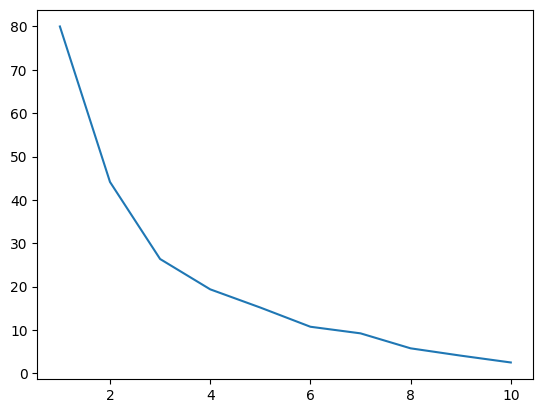

In [109]:
from sklearn.cluster import KMeans

inertia_scores3 = []

for i in range(1,11):
    kmeans3 = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans3.fit(dff)
    inertia_scores3.append(kmeans3.inertia_)
plt.plot(range(1,11),inertia_scores3)   
    

In [110]:
df

,Gender,Age,Annual_Income,Spending_Score,Income Cluster,Spending and Income Cluster
0,Male,22,15000,39,1,2
1,Female,25,18000,81,1,2
2,Female,47,50000,6,2,1
3,Male,52,60000,77,0,4
4,Male,46,52000,40,2,1
5,Female,23,20000,76,1,2
6,Female,30,30000,6,1,0
7,Male,35,35000,94,1,0
8,Male,28,27000,3,1,0
9,Female,40,48000,72,2,3


In [111]:
df.to_csv('Clustering.csv')